# Midterm

## Objective

In this assignment, we will work on change detection and blob matching tasks. Change detection is based on a loop, where at each time frame, you will compare the current frame $I_t$ with a reference image or background B. 

## Pipeline
1. **Background initialization:** the background is usually initialised ($B_0$) by taking an average of the first few frames (hoping/assuming they are empty).
2. **Change detection:** at each time $t$
    - Update background $B_t$ (this is an optional step, in the first versions, you may set it constant to $B_0$)
    - Compute the change detection map $M_t$ by comparing $B_t$ with $I_t$
3. **Compute connected components** (also called BLOBS):
    - Each group of connected pixels marked as changes might be labelled with a common label, producing a connected component
    - To perform this step, we will use library functions (either skimage or opencv)
4. **Map cleaning:**
    - Cancel small connected components
    - Apply morphological operations to make the connected component smoother and more compact.
5. **Blob matching:** 
    - At this point, the frame-based analysis is finished, and we can start discussing how we can connect components over time
    - To do so, we will compute matches between connected components in $M_t$ and $M_{t+1}$
    matches may be based on vicinity (e.g., Euclidean distance between blob centroids) or even similarity (e.g., average intensity/colour within the blob, area, shape descriptors, ...)


## Imports

In [62]:
import os
import numpy as np
from scipy import signal, spatial
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from skimage import draw as drw
from skimage import data, color, exposure, img_as_float, img_as_ubyte, morphology, filters, measure, util
from skimage import io
import cv2

import skimage
%matplotlib inline

PATH = 'station_video_frames/'
ES1 = 'es1/'
ES2 = 'es2/'

## Import Frames

In [2]:
def preprocessing(img):
    return img_as_float(color.rgb2gray(img))

def import_images(path):
    images = []
    for filename in sorted(os.listdir(path)):
        img = io.imread(os.path.join(path, filename))
        if img is not None:
            images.append(preprocessing(img))
    return images

## Import Background

In [3]:
def background_init(frames):
    return np.average(frames,axis=0)

## Change detection and thresholding

The binary change map is obtained from the absolute difference $D_t = |I_t - B|$ by $M_t = D_t > \tau$.

### Choosing $\tau$ (heuristics)

- **Fixed / manual:** chosen by trial and error for a given dataset (simple baseline).
- **Mean + $k\sigma$:** $\tau = \mathrm{mean}(D) + k \,\mathrm{std}(D)$; reasonable when most pixels belong to static background.
- **Robust (median + scaled MAD):** less sensitive than mean/std when the moving region covers a non-negligible fraction of the image.
- **High percentile:** $\tau$ at the $p$-th percentile of $D$ (e.g. 99.5th) — treats the bulk of pixels as background.
- **Background core:** estimate mean and std using only the **smallest** values of $D$ (e.g. lowest 50%), then $\tau = \mu + k\sigma$ — approximates noise in “static” pixels even when change occupies a larger area.

### Otsu's method

Otsu selects a threshold by maximizing between-class variance of the **histogram** of $D$. It assumes an approximately **bimodal** distribution (e.g. unchanged vs changed). It can work well when changed pixels form a clear second mode; it may be **less reliable** when the difference image is **unimodal** (small or gradual changes, global illumination), when foreground is tiny, or when noise dominates — then robust heuristics or a manual $\tau$ are often preferable.

The code below implements $D$, several heuristics for $\tau$, Otsu, and binarization. Use `change_detection(...)` for a fixed $\tau$ (backward compatible with the rest of the notebook).

In [104]:
def difference_map(frame, ref):
    """Absolute difference |I - B| in float64 for stable statistics."""
    f = np.asarray(frame, dtype=np.float64)
    r = np.asarray(ref, dtype=np.float64)
    return np.abs(f - r)


def binarize_change(diff, tau):
    """Binary change mask: D > tau."""
    return diff > tau


def change_detection(frame, ref, threshold=0.1):
    """Fixed threshold tau (same units as float grayscale in [0, 1])."""
    return binarize_change(difference_map(frame, ref), threshold)


def tau_heuristic_mean_std(diff, k=3.0):
    """tau = mean(D) + k * std(D)."""
    d = diff.ravel()
    return float(np.mean(d) + k * np.std(d))


def tau_heuristic_median_mad(diff, k=3.0):
    """tau = median(D) + k * (MAD / 0.6745). Robust to heavy-tailed |D|."""
    d = np.abs(np.asarray(diff).ravel())
    med = np.median(d)
    mad = np.median(np.abs(d - med))
    sigma_hat = mad / 0.6745 if mad > 0 else 0.0
    return float(med + k * sigma_hat)


def tau_heuristic_percentile(diff, p=99.5):
    """tau at the p-th percentile of D (high tail = change)."""
    return float(np.percentile(diff, p))


def tau_heuristic_background_core(diff, quantile=0.5, k=3.0):
    """Use lowest `quantile` fraction of D values to estimate background noise; tau = mu + k*sigma."""
    d = np.sort(diff.ravel())
    n = max(int(len(d) * quantile), 1)
    core = d[:n]
    return float(np.mean(core) + k * np.std(core))


def tau_otsu(diff):
    """Otsu threshold on D. Constant images fall back to the single level."""
    d = np.asarray(diff)
    if np.ptp(d) == 0:
        return float(d.ravel()[0])
    return float(filters.threshold_otsu(d))


def change_detection_with_tau(frame, ref, tau):
    """Binarize using an explicit tau (for experiments comparing estimators)."""
    diff = difference_map(frame, ref)
    return binarize_change(diff, tau), diff


def change_detection_otsu(frame, ref):
    """Otsu-selected tau; returns (mask, diff, tau)."""
    diff = difference_map(frame, ref)
    tau = tau_otsu(diff)
    return binarize_change(diff, tau), diff, tau


def summarize_tau_methods(diff):
    """Return a dict of method name -> tau for logging and tables."""
    return {
        "mean + 3σ": tau_heuristic_mean_std(diff, k=3.0),
        "median + 3·MAD": tau_heuristic_median_mad(diff, k=3.0),
        "p99.5": tau_heuristic_percentile(diff, p=99.5),
        "bg-core + 3σ (q=0.5)": tau_heuristic_background_core(diff, quantile=0.5, k=3.0),
        "Otsu": tau_otsu(diff),
    }


def running_average(frame, ref, threshold=0.1, alpha=0.1):
    changes = change_detection(frame, ref, threshold)
    return changes, np.where(changes, ref, (1 - alpha) * ref + alpha * frame)

## Connected components

In [28]:
def compute_cc(changes):
    label_image = measure.label(changes)
    return label_image, measure.regionprops(label_image)

## Map cleaning

In [6]:
def map_cleaning(changes):
    final_changes = morphology.closing(changes,morphology.disk(2))
    return morphology.remove_small_objects(final_changes,100)

## Blob matching

In [60]:
def spatial_distance(c1, c2, sigma):
    dist = spatial.distance.cdist(c1, c2)
    return np.exp(-(dist**2) / (2 * sigma * sigma)) 

def compute_distances(c1, c2, sigma=0.2):
    return spatial_distance(c1, c2, sigma)

def similarity_matrix(blobs1,blobs2,sigma=0.25,weight=0.5):
    pos1 = [b.centroid for b in blobs1]
    pos2 = [b.centroid for b in blobs2]
    E = compute_distances(pos1,pos2,sigma)

    argmaxE_h = np.argmax(E, axis=1) 
    argmaxE_v = np.argmax(E, axis=0) 
    match = []

    for i, amx in enumerate(argmaxE_h):
        if argmaxE_v[amx] == i:
            match.append((i,amx))
            
    match = np.array(match)

    return E, match

## Background initialization

In [12]:
bg_fixed = preprocessing(io.imread(PATH + ES1 + 'Background.jpg'))
bg_aux = []
bg_aux.append(preprocessing(io.imread(PATH + ES1 + 'EmptyScene01.jpg')))
bg_aux.append(preprocessing(io.imread(PATH + ES1 + 'EmptyScene02.jpg')))
bg_avg = background_init(bg_aux)

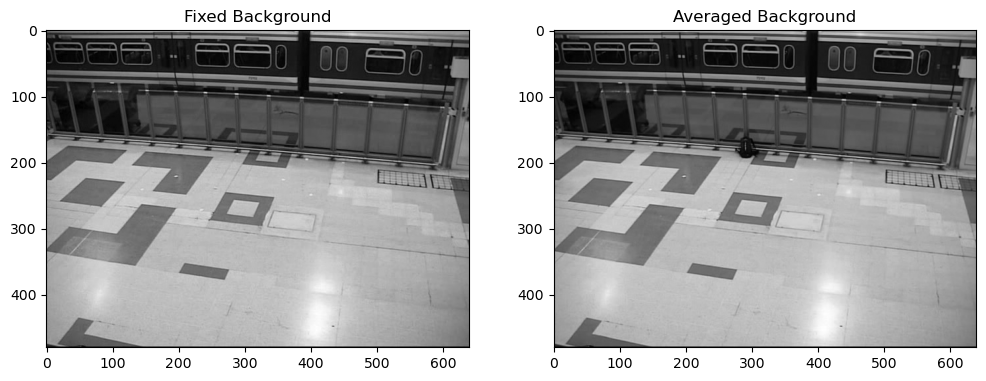

In [13]:
plt.figure(figsize=(12,8))
plt.subplot(121)
plt.imshow(bg_fixed,cmap='gray')
plt.title('Fixed Background')
plt.subplot(122)
plt.imshow(bg_avg,cmap='gray')
plt.title('Averaged Background')
plt.show()

## Sample frames

In [11]:
es1_frames = import_images(PATH + ES1 + "video/")

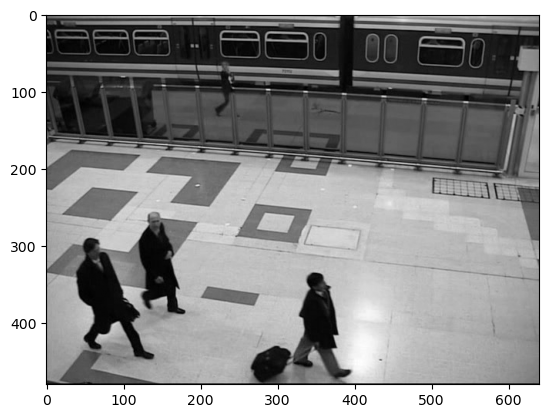

In [32]:
plt.imshow(es1_frames[50],cmap='gray')
plt.show()

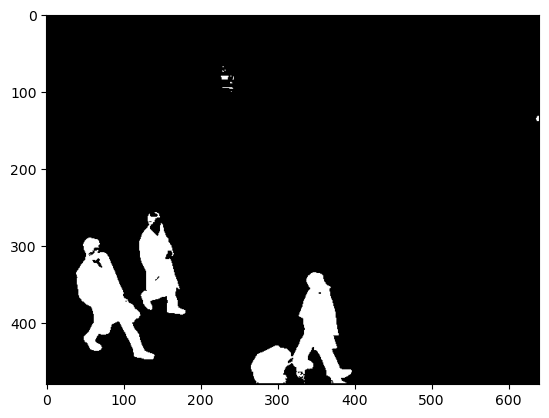

In [19]:
# Thresholding comparison on one frame (experimental analysis)
diff = difference_map(bg_fixed, es1_frames[50])
taus = summarize_tau_methods(diff)
tau_manual = 0.25  # original notebook setting

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

axes[0].imshow(diff, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("|I − B| (difference map)")
axes[0].axis("off")

# Histogram: applicability of Otsu (bimodal vs unimodal is visible qualitatively)
axes[1].hist(diff.ravel(), bins=128, range=(0, 1), color="steelblue", alpha=0.85)
axes[1].axvline(tau_manual, color="orange", linestyle="--", label=f"manual τ={tau_manual}")
axes[1].axvline(taus["Otsu"], color="red", label=f"Otsu τ={taus['Otsu']:.4f}")
axes[1].set_xlim(0, 1)
axes[1].set_title("Histogram of D (Otsu assumes separable modes)")
axes[1].legend(fontsize=8)
axes[1].set_xlabel("D")

masks_titles = [
    (change_detection(bg_fixed, es1_frames[50], tau_manual), f"manual τ={tau_manual}"),
    (binarize_change(diff, taus["mean + 3σ"]), f"mean+3σ → τ={taus['mean + 3σ']:.4f}"),
    (binarize_change(diff, taus["Otsu"]), f"Otsu → τ={taus['Otsu']:.4f}"),
    (binarize_change(diff, taus["bg-core + 3σ (q=0.5)"]), f"bg-core → τ={taus['bg-core + 3σ (q=0.5)']:.4f}"),
]
for ax, (mask, title) in zip(axes[2:], masks_titles):
    ax.imshow(mask, cmap="gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("τ values (same frame):")
for name, t in {**{"manual": tau_manual}, **taus}.items():
    print(f"  {name:22s} {t:.6f}")

### Experimental notes (thresholding)

When you interpret the plots above: check whether the histogram of $D$ is **bimodal**. Otsu is motivated by a mixture of two classes; a single dominant peak usually means Otsu is a weaker choice than robust statistics or a tuned manual $\tau$. Compare **false positives** (speckle in static regions) versus **missed detections** across methods. Remember that **global illumination** shifts $D$ for many pixels at once — per-frame adaptive $\tau$ or background-core noise estimates often cope better than one fixed $\tau$ for the whole sequence.

In [23]:
changes = map_cleaning(changes)

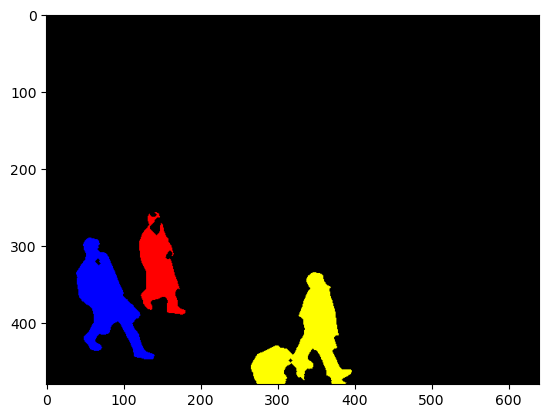

In [31]:
blobs_img, blob_props = compute_cc(changes)
colored_label_image = color.label2rgb(blobs_img, bg_label=0)

plt.imshow(colored_label_image)
plt.show()

In [97]:
def get_id_color(obj_id):
    """Returns a specific, high-visibility BGR color based on the ID."""
    # Palette: Green, Orange, Red, Cyan, Magenta, Yellow, Sky Blue, Hot Pink
    palette = [
        (0, 255, 0),      # Green
        (0, 165, 255),    # Orange
        (0, 0, 255),      # Red
        (255, 255, 0),    # Cyan
        (255, 0, 255),    # Magenta
        (0, 255, 255),    # Yellow
        (255, 191, 0),    # Deep Sky Blue
        (180, 105, 255)   # Hot Pink
    ]
    return palette[int(obj_id) % len(palette)]

def compute_visual_frame(frame, label_image, props):
    out_img = util.img_as_ubyte(frame)
    if len(out_img.shape) == 2: # If grayscale, convert to RGB
        out_img = cv2.cvtColor(out_img, cv2.COLOR_GRAY2RGB)

    fixed_color = (255, 255, 0) 
    visual_frame = out_img.copy()
    mask = label_image > 0
    visual_frame[mask] = fixed_color

    alpha = 0.3
    visual_frame = cv2.addWeighted(visual_frame, alpha, out_img, 1 - alpha, 0)

    for prop in props:
        y, x = prop.centroid
        pos = (int(x), int(y))
        cv2.putText(visual_frame, f"ID:{prop.label}", pos, 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    
    return visual_frame

In [91]:
final_frames_algo1 = []
moving_bg = bg_fixed.copy()
for frame in es1_frames:
    changes = change_detection(moving_bg,frame,0.1)

    changes = map_cleaning(changes)
    blobs_img, blob_props = compute_cc(changes)

    annotated = compute_visual_frame(frame, blobs_img, blob_props)
    final_frames_algo1.append(annotated)

In [106]:
final_frames_algo2 = []
moving_bg = bg_fixed.copy()
for frame in es1_frames:
    changes, moving_bg = running_average(moving_bg,frame,0.1)

    changes = map_cleaning(changes)
    blobs_img, blob_props = compute_cc(changes)

    annotated = compute_visual_frame(frame, blobs_img, blob_props)
    final_frames_algo2.append(annotated)

In [107]:
final_frames = final_frames_algo2

# 1. Define video parameters
height, width, layers = final_frames[0].shape
size = (width, height)
fps = 24  # Adjust based on your source data
output_filename = 'object_tracking_output.mp4'

# 2. Initialize VideoWriter 
# 'mp4v' is widely compatible; 'avc1' is better if you have openh264 installed
out = cv2.VideoWriter(output_filename, cv2.VideoWriter_fourcc(*'mp4v'), fps, size)

for frame in final_frames:
    # OpenCV expects BGR, but your images are likely RGB from skimage/matplotlib
    # Convert RGB to BGR for the writer
    bgr_frame = cv2.cvtColor(frame.astype(np.uint8), cv2.COLOR_RGB2BGR)
    out.write(bgr_frame)

out.release()
print(f"Video saved as {output_filename}")

import subprocess
from IPython.display import Video

input_file = 'object_tracking_output.mp4'
output_file = 'final_browser_video.mp4'

# Use subprocess to catch output and avoid the 'red block' in Jupyter
cmd = f"ffmpeg -i {input_file} -vcodec libopenh264 -f mp4 -y {output_file}"

try:
    # check=True will raise an error if the command fails
    # stderr=subprocess.STDOUT merges error messages into the output
    subprocess.run(cmd.split(), check=True, capture_output=True, text=True)
    print("✅ Conversion successful! Displaying video...")
    display(Video(output_file, embed=True, width=800))
except subprocess.CalledProcessError as e:
    print("❌ FFMPEG Error:")
    print(e.stderr)

Video saved as object_tracking_output.mp4
✅ Conversion successful! Displaying video...


In [111]:
# --- The Main Tracking Loop ---
tracks = {} 
next_id = 0
prev_blobs = []
prev_id_map = [] 
final_frames_with_lines = []
moving_bg = bg_fixed.copy()

for frame in es1_frames:
    # 1. Detection
    changes = change_detection(moving_bg, frame, 0.1)
    changes = map_cleaning(changes)
    blobs_img, current_blobs = compute_cc(changes) 
    
    current_id_map = [-1] * len(current_blobs)
    
    if prev_blobs and current_blobs:
        # 2. Matching
        E, matches = similarity_matrix(prev_blobs, current_blobs, sigma=20.0)
        
        # 3. Update existing tracks
        if len(matches) > 0:
            for prev_idx, curr_idx in matches:
                matched_id = prev_id_map[prev_idx]
                current_id_map[curr_idx] = matched_id
                
                y, x = current_blobs[curr_idx].centroid
                tracks[matched_id].append((int(x), int(y)))

    # 4. Register new blobs
    for i, blob in enumerate(current_blobs):
        if current_id_map[i] == -1:
            y, x = blob.centroid
            tracks[next_id] = [(int(x), int(y))]
            current_id_map[i] = next_id
            next_id += 1

    # 5. Drawing (The Lines)
    # Use your visual frame function first (for the blobs and text)
    out_img = compute_visual_frame(frame, blobs_img, current_blobs) 
    
    for obj_id, points in tracks.items():
        if len(points) > 1:
            # Get the UNIQUE color for this ID
            line_color = get_id_color(obj_id)
            
            # Draw the path using cv2.polylines
            pts = np.array(points).reshape((-1, 1, 2))
            cv2.polylines(out_img, [pts], isClosed=False, color=line_color, thickness=4)

    final_frames_with_lines.append(out_img)
    
    # Prep for next frame
    prev_blobs = current_blobs
    prev_id_map = current_id_map

In [112]:
final_frames = final_frames_with_lines

# 1. Define video parameters
height, width, layers = final_frames[0].shape
size = (width, height)
fps = 24  # Adjust based on your source data
output_filename = 'object_tracking_output.mp4'

# 2. Initialize VideoWriter 
# 'mp4v' is widely compatible; 'avc1' is better if you have openh264 installed
out = cv2.VideoWriter(output_filename, cv2.VideoWriter_fourcc(*'mp4v'), fps, size)

for frame in final_frames:
    # OpenCV expects BGR, but your images are likely RGB from skimage/matplotlib
    # Convert RGB to BGR for the writer
    bgr_frame = cv2.cvtColor(frame.astype(np.uint8), cv2.COLOR_RGB2BGR)
    out.write(bgr_frame)

out.release()
print(f"Video saved as {output_filename}")

import subprocess
from IPython.display import Video

input_file = 'object_tracking_output.mp4'
output_file = 'final_browser_video.mp4'

# Use subprocess to catch output and avoid the 'red block' in Jupyter
cmd = f"ffmpeg -i {input_file} -vcodec libopenh264 -f mp4 -y {output_file}"

try:
    # check=True will raise an error if the command fails
    # stderr=subprocess.STDOUT merges error messages into the output
    subprocess.run(cmd.split(), check=True, capture_output=True, text=True)
    print("✅ Conversion successful! Displaying video...")
    display(Video(output_file, embed=True, width=800))
except subprocess.CalledProcessError as e:
    print("❌ FFMPEG Error:")
    print(e.stderr)

Video saved as object_tracking_output.mp4
✅ Conversion successful! Displaying video...
